# Composite heat fluxes during MHW events
# SPEAR-LO
(had to submit 4 jobs for the 4 scripts I ran in parallel to composite the HFs, took 5.5-7.5hrs. `1c2a_composite_{hf}.py`)

In [1]:
import xarray as xr
import pandas as pd
import json
import numpy as np
import cmocean
import cartopy.crs as ccrs #cartopy coord ref sys
import cartopy
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.colors import LogNorm
import matplotlib.colors as mcolors
from matplotlib.colors import TwoSlopeNorm
from matplotlib.colors import ListedColormap
import time
from tqdm import tqdm
import glob
import os
from collections import defaultdict
import xesmf as xe
import ast #for parsing through events_by_cell.json file

## checking global avg of HFs to check if signs are correct
(had to switch `SH` sign...I think it follows ERA5 convention of positive out of the ocean..whereas `LW`/`SW` follow atm convention)

In [77]:
lw = xr.open_dataset('/archive/wfc/SPEAR/SPEAR_c384_OM4p25_Hist_SSP245_IC1991_R61_ens_01/pp/atmos_daily/ts/daily/1yr/atmos_daily.19910101-19911231.lwflx.nc',
                    decode_timedelta=True, chunks={})
swdn = xr.open_dataset('/archive/wfc/SPEAR/SPEAR_c384_OM4p25_Hist_SSP245_IC1991_R61_ens_01/pp/atmos_daily/ts/daily/1yr/atmos_daily.19910101-19911231.swdn_sfc.nc',
                    decode_timedelta=True, chunks={})
swup = xr.open_dataset('/archive/wfc/SPEAR/SPEAR_c384_OM4p25_Hist_SSP245_IC1991_R61_ens_01/pp/atmos_daily/ts/daily/1yr/atmos_daily.19910101-19911231.swup_sfc.nc',
                    decode_timedelta=True, chunks={})
lh = xr.open_dataset('/archive/wfc/SPEAR/SPEAR_c384_OM4p25_Hist_SSP245_IC1991_R61_ens_01/pp/atmos_daily/ts/daily/1yr/atmos_daily.19910101-19911231.evap.nc',
                    decode_timedelta=True, chunks={})
sh = xr.open_dataset('/archive/wfc/SPEAR/SPEAR_c384_OM4p25_Hist_SSP245_IC1991_R61_ens_01/pp/atmos_daily/ts/daily/1yr/atmos_daily.19910101-19911231.shflx.nc',
                    decode_timedelta=True, chunks={})

- lw : net (down-up) longwave flux (positive downward, negative -> ocean losing heat)
- swdn : SW flux down at surface
- swup : SW flux up at surface
- sw : swdn-swup (positive downward, positive -> ocean gaining heat)
- lh : evaporation rate `* -2.5e6` (positive downward, negative -> ocean losing heat)
- sh : sensible heat flux

In [ ]:
SW (shortwave) → ☀️ always positive (heats ocean)
LW (longwave) → 🌍 typically negative (ocean emits IR)
LH (latent) → 💨 negative (evaporation cools ocean)
SH (sensible) → 🌬️ usually negative (ocean loses heat to air)

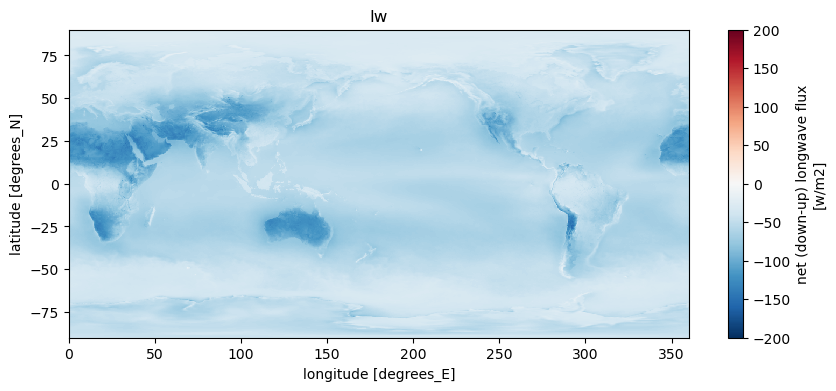

In [91]:
lw.lwflx.mean('time').plot(figsize=(10,4), vmin=-200, vmax=200, cmap='RdBu_r')
plt.title('lw');

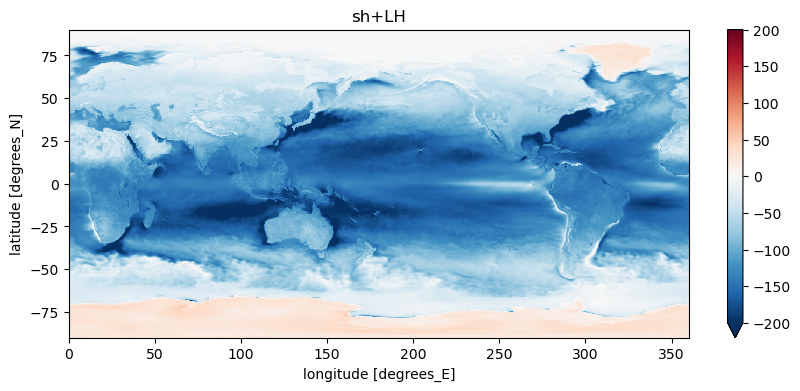

In [98]:
((-sh.shflx)+(lh.evap*-2.5e6)).mean('time').plot(figsize=(10,4), vmin=-200, vmax=200, cmap='RdBu_r')
plt.title('sh+LH');

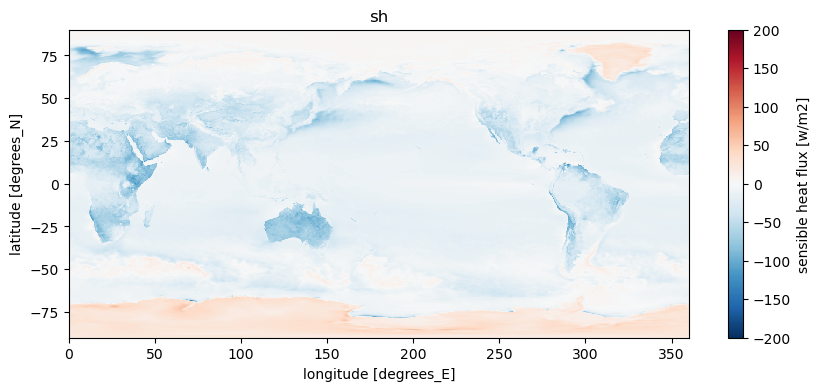

In [97]:
(-sh.shflx).mean('time').plot(figsize=(10,4), vmin=-200, vmax=200, cmap='RdBu_r')
plt.title('sh');

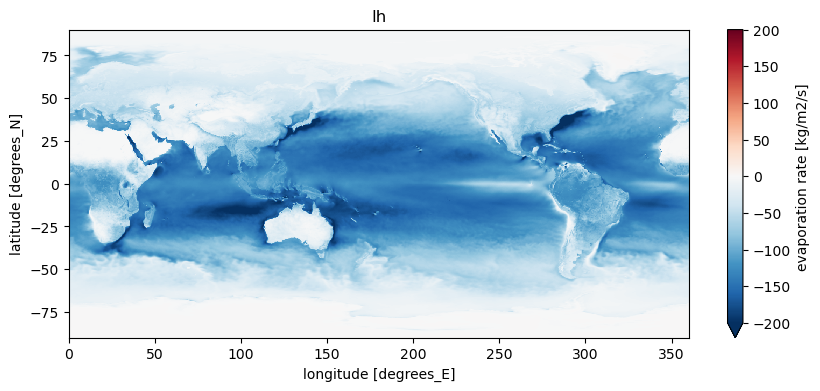

In [96]:
(lh.evap*-2.5e6).mean('time').plot(figsize=(10,4), vmin=-200, vmax=200, cmap='RdBu_r')
plt.title('lh');

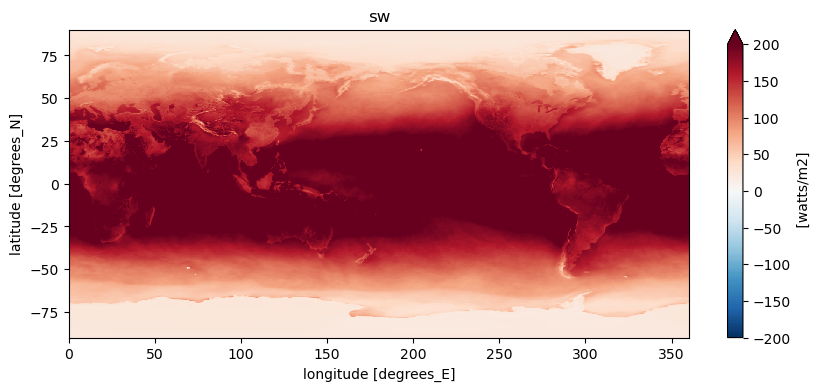

In [94]:
(swdn.swdn_sfc-swup.swup_sfc).mean('time').plot(figsize=(10,4), vmin=-200, vmax=200, cmap='RdBu_r')
plt.title('sw');

## Open flux datasets

In [2]:
def open_fluxes(filename, var_name, quantile=True):
    path = '/work/stb/MHW-gfdl/SPEAR/vars/SPEAR-HI25/period_1991-2024/composites/ens-mean/'
    hfs = ['lwflx', 'shflx', 'lhflx', 'swflx']
    
    if quantile==False:
        flx_ds = xr.merge([xr.open_dataset(f'{path}{var}{filename}.nc', chunks={}).rename({var_name:var}) 
                             for var in hfs])
    else:
        flx_ds = xr.merge([xr.open_dataset(f'{path}{var}{filename}.nc', chunks={}).rename({var_name:var}).drop_vars('quantile') 
                             for var in hfs])
    return flx_ds

In [3]:
flx_em = open_fluxes('_mhw_composite', 'flux_mhw_ens_mean')
flx_clim = open_fluxes('_clim_ens_mean', 'flux_clim_ens_mean', quantile=False)
flx_anom = open_fluxes('_mhw_anom_composite', 'flux_anom_mhw_ens_mean')
flx_seas_anom = open_fluxes('_mhw_anom_season_composite', 'flux_anom_mhw_season_ens_mean')
flx_diff = open_fluxes('_diff_composite', 'diff_ens_mean_flux')
flx_noem = open_fluxes('_nomhw_composite', 'flux_nomhw_ens_mean')
flx_noanom = open_fluxes('_nomhw_anom_composite', 'flux_anom_nomhw_ens_mean')
flx_noseas_anom = open_fluxes('_nomhw_anom_season_composite', 'flux_anom_nomhw_season_ens_mean')

In [4]:
#flip `shflx` sign
flx_em['shflx'] = -flx_em.shflx
flx_clim['shflx'] = -flx_clim.shflx
flx_anom['shflx'] = -flx_anom.shflx
flx_seas_anom['shflx'] = -flx_seas_anom.shflx
flx_diff['shflx'] = -flx_diff.shflx
flx_noem['shflx'] = -flx_noem.shflx
flx_noanom['shflx'] = -flx_noanom.shflx
flx_noseas_anom['shflx'] = -flx_noseas_anom.shflx

In [5]:
flx_em

<xarray.Dataset> Size: 471kB
Dimensions:  (yT: 90, xT: 325)
Coordinates:
  * yT       (yT) float64 720B 10.2 10.44 10.69 10.93 ... 30.46 30.67 30.89
  * xT       (xT) float64 3kB -97.84 -97.58 -97.33 ... -16.65 -16.4 -16.15
Data variables:
    lwflx    (yT, xT) float32 117kB dask.array<chunksize=(90, 325), meta=np.ndarray>
    shflx    (yT, xT) float32 117kB dask.array<chunksize=(90, 325), meta=np.ndarray>
    lhflx    (yT, xT) float32 117kB dask.array<chunksize=(90, 325), meta=np.ndarray>
    swflx    (yT, xT) float32 117kB dask.array<chunksize=(90, 325), meta=np.ndarray>

In [6]:
flx_clim

<xarray.Dataset> Size: 171MB
Dimensions:    (dayofyear: 366, yT: 90, xT: 325)
Coordinates:
  * dayofyear  (dayofyear) int64 3kB 1 2 3 4 5 6 7 ... 361 362 363 364 365 366
  * yT         (yT) float64 720B 10.2 10.44 10.69 10.93 ... 30.46 30.67 30.89
  * xT         (xT) float64 3kB -97.84 -97.58 -97.33 ... -16.65 -16.4 -16.15
Data variables:
    lwflx      (dayofyear, yT, xT) float32 43MB dask.array<chunksize=(366, 90, 325), meta=np.ndarray>
    shflx      (dayofyear, yT, xT) float32 43MB dask.array<chunksize=(366, 90, 325), meta=np.ndarray>
    lhflx      (dayofyear, yT, xT) float32 43MB dask.array<chunksize=(366, 90, 325), meta=np.ndarray>
    swflx      (dayofyear, yT, xT) float32 43MB dask.array<chunksize=(366, 90, 325), meta=np.ndarray>

## Plotting func

In [8]:
def cartopy_plot_2x2(da_list, cmap_choice, cbar_label, var_titles, vmin=None, vmax=None, norm=None, fig_title=None):
    proj = ccrs.Mercator()
    fig, axes = plt.subplots( 2, 2, figsize=(12, 6), subplot_kw=dict(projection=proj), gridspec_kw={'hspace': 0.02, 'wspace': 0.15}) 
    axes = axes.flatten()

    lat_candidates = ['lat', 'latitude', 'yT', 'yh']
    lon_candidates = ['lon', 'longitude', 'xT', 'xh']
    
    if norm is None:
        norm = colors.Normalize(vmin=vmin, vmax=vmax)
    else:
        norm = colors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
        if vmin is not None:
            norm.vmin = vmin
        if vmax is not None:
            norm.vmax = vmax

    ims = []
    for i, (ax, da, title) in enumerate(zip(axes, da_list, var_titles)):
        ax.set_extent([-98, -60, 17.5, 31], crs=ccrs.PlateCarree())
        ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '50m', edgecolor='face', facecolor='0.5'))

        lat_name = next((c for c in lat_candidates if c in da.coords), None)
        lon_name = next((c for c in lon_candidates if c in da.coords), None)

        if lat_name is None or lon_name is None:
            raise ValueError(f"Could not infer lat/lon. Found coords: {list(da.coords)}")

        im = ax.pcolormesh(da[lon_name], da[lat_name], da, transform=ccrs.PlateCarree(), norm=norm, cmap=cmap_choice)
        ims.append(im)

        # --- determine subplot position ---
        row = i // 2
        col = i % 2

        # --- gridlines + labels ---
        g1 = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True)
        g1.top_labels = False
        g1.right_labels = False
        g1.bottom_labels = (row == 1)   # only bottom row
        g1.left_labels   = (col == 0)   # only left column
        g1.xlabel_style = {'size': 9}
        g1.ylabel_style = {'size': 9}
        # optional: subtle gridlines
        g1.linestyle = ':'
        g1.alpha = 0.5

        ax.set_title(title, fontsize=13)

    # --- colorbar aligned with subplot grid ---
    cb = fig.colorbar(ims[0], ax=axes, orientation='vertical', fraction=0.02, pad=0.03)
    cb.set_label(cbar_label, fontsize=12)

    # --- title ---
    if fig_title:
        fig.suptitle(fig_title, fontsize=15, y=0.94)

    return fig, axes

In [9]:
#plotting func
def cartopy_plot_single(da, cmap_choice, cbar_label, var_title, vmin=None, vmax=None, norm=None, quiver=True):
    proj = ccrs.Mercator() #with Mercator you can put lat lon values.
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection=proj))
    ax.set_extent([-98, -60, 17.5, 30.5], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                            edgecolor='face',
                                            facecolor='0.5'))
    # ---- infer coord names if not provided ----
    lat_candidates = ['lat', 'latitude', 'yT', 'yh']
    lon_candidates = ['lon', 'longitude', 'xT', 'xh']

    lat_name = next((c for c in lat_candidates if c in da.coords), None)
    lon_name = next((c for c in lon_candidates if c in da.coords), None)

    if lat_name is None or lon_name is None:
        raise ValueError(
            f"Could not infer lat/lon coordinates. "
            f"Found coords: {list(da.coords)}"
        )

    lats = da[lat_name]
    lons = da[lon_name]

    # ---- normalization logic ----
    if norm is None:
        norm = colors.Normalize(vmin=vmin, vmax=vmax)
    else:
        norm = colors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
        if vmin is not None:
            norm.vmin = vmin
        if vmax is not None:
            norm.vmax = vmax
    # -------------------------------------------------------------------------------
    im = ax.pcolormesh(lons, lats, da, transform=ccrs.PlateCarree(), 
                       norm=norm, cmap=cmap_choice)
    cb = fig.colorbar(im, ax=ax, shrink=0.25, pad=0.1)
    cb.set_label(fr"{cbar_label}", labelpad=8, fontsize=12)
    g1 = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True)
    g1.xlabels_top = False
    g1.ylabels_right = False
    plt.title(f'{var_title}', fontsize=14, y=1.09)

## Plot diff and anoms composites during MHWs

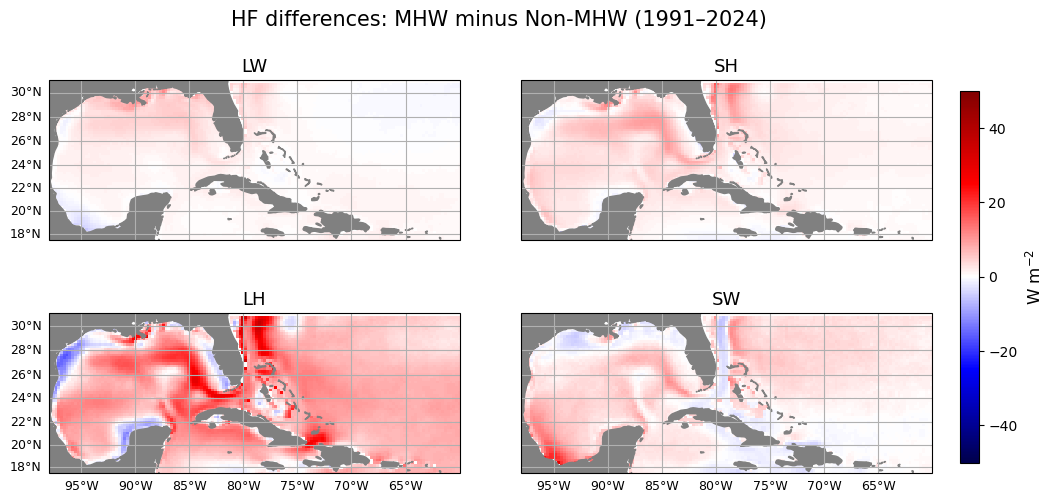

In [10]:
da_list = [flx_diff.lwflx, flx_diff.shflx, flx_diff.lhflx, flx_diff.swflx]
titles  = ['LW', 'SH', 'LH', 'SW']

fig, axes = cartopy_plot_2x2(da_list = da_list, cmap_choice = 'seismic', cbar_label=r'W m$^{-2}$', 
                             var_titles=titles, vmin=-50, vmax=50, fig_title='HF differences: MHW minus Non-MHW (1991–2024)')
#plt.show()

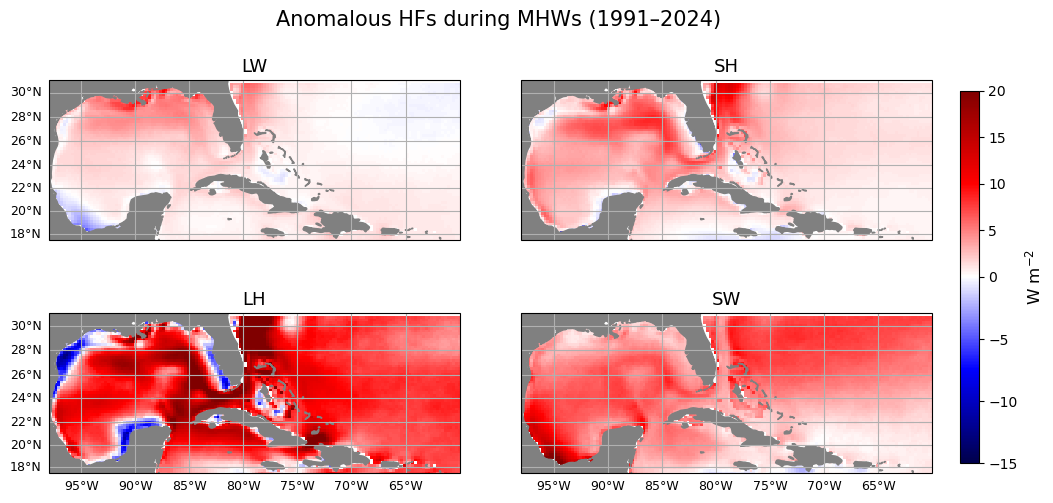

In [11]:
da_list = [flx_anom.lwflx, flx_anom.shflx, flx_anom.lhflx, flx_anom.swflx]
titles  = ['LW', 'SH', 'LH', 'SW']

fig, axes = cartopy_plot_2x2(da_list = da_list, cmap_choice = 'seismic', cbar_label=r'W m$^{-2}$', 
                             var_titles=titles, norm=colors.TwoSlopeNorm, vmin=-15, vmax=20, 
                             fig_title='Anomalous HFs during MHWs (1991–2024)')

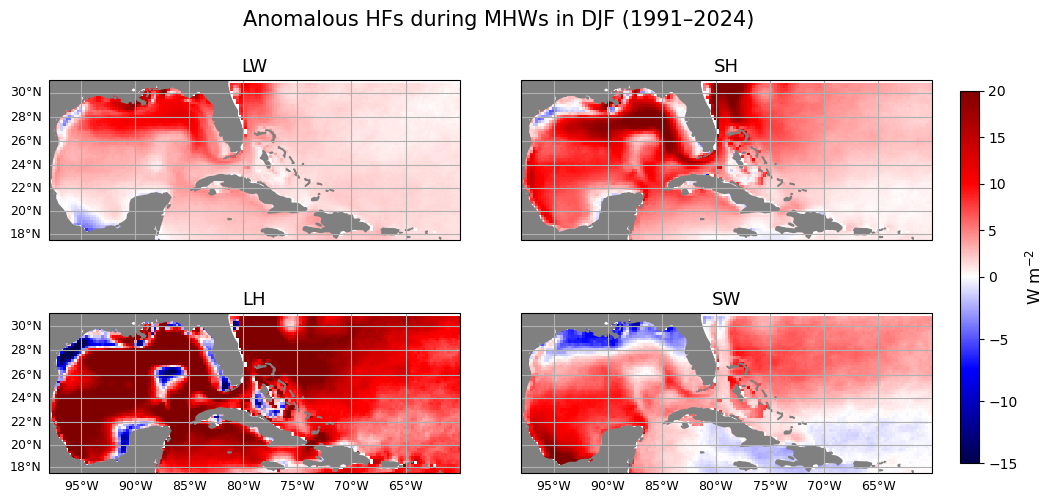

In [12]:
da_list = [flx_seas_anom.sel(season='DJF').lwflx, flx_seas_anom.sel(season='DJF').shflx, 
           flx_seas_anom.sel(season='DJF').lhflx, flx_seas_anom.sel(season='DJF').swflx]
titles  = ['LW', 'SH', 'LH', 'SW']

fig, axes = cartopy_plot_2x2(da_list = da_list, cmap_choice = 'seismic', cbar_label=r'W m$^{-2}$', 
                             var_titles=titles, norm=colors.TwoSlopeNorm, vmin=-15, vmax=20, 
                             fig_title='Anomalous HFs during MHWs in DJF (1991–2024)')

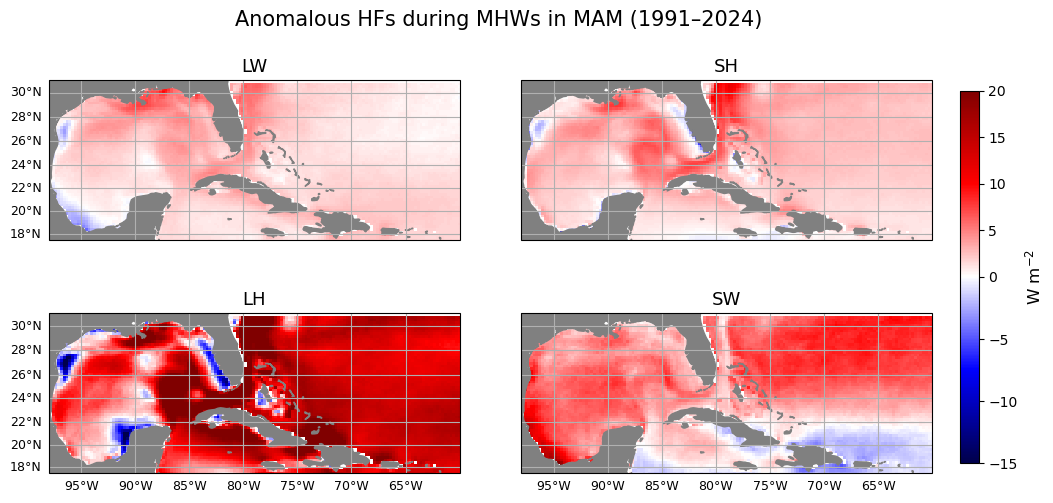

In [13]:
da_list = [flx_seas_anom.sel(season='MAM').lwflx, flx_seas_anom.sel(season='MAM').shflx, 
           flx_seas_anom.sel(season='MAM').lhflx, flx_seas_anom.sel(season='MAM').swflx]
titles  = ['LW', 'SH', 'LH', 'SW']

fig, axes = cartopy_plot_2x2(da_list = da_list, cmap_choice = 'seismic', cbar_label=r'W m$^{-2}$', 
                             var_titles=titles, norm=colors.TwoSlopeNorm, vmin=-15, vmax=20, 
                             fig_title='Anomalous HFs during MHWs in MAM (1991–2024)')

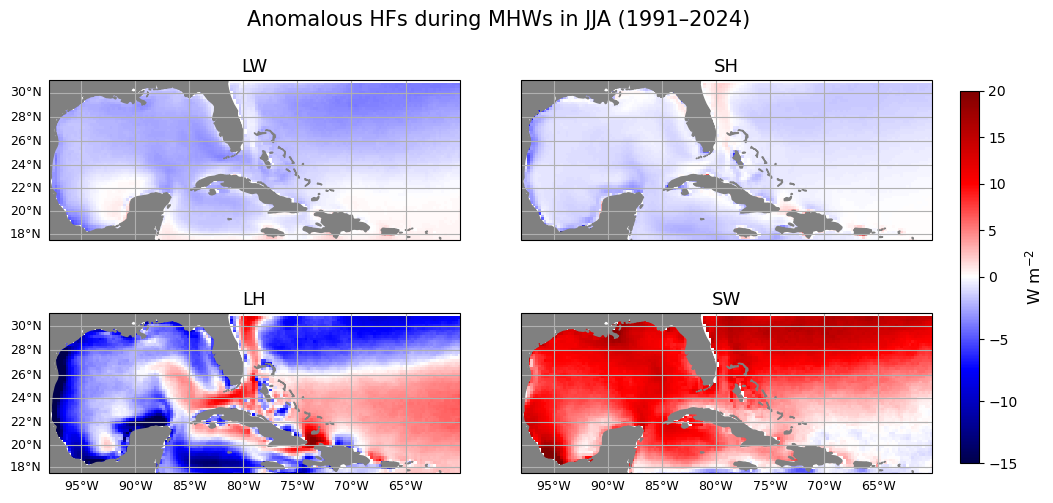

In [14]:
da_list = [flx_seas_anom.sel(season='JJA').lwflx, flx_seas_anom.sel(season='JJA').shflx, 
           flx_seas_anom.sel(season='JJA').lhflx, flx_seas_anom.sel(season='JJA').swflx]
titles  = ['LW', 'SH', 'LH', 'SW']

fig, axes = cartopy_plot_2x2(da_list = da_list, cmap_choice = 'seismic', cbar_label=r'W m$^{-2}$', 
                             var_titles=titles, norm=colors.TwoSlopeNorm, vmin=-15, vmax=20, 
                             fig_title='Anomalous HFs during MHWs in JJA (1991–2024)')

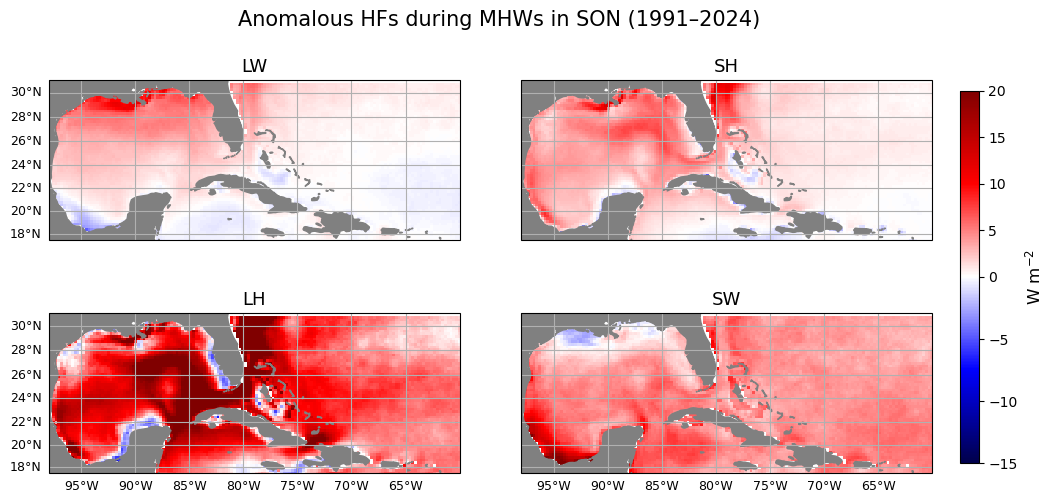

In [15]:
da_list = [flx_seas_anom.sel(season='SON').lwflx, flx_seas_anom.sel(season='SON').shflx, 
           flx_seas_anom.sel(season='SON').lhflx, flx_seas_anom.sel(season='SON').swflx]
titles  = ['LW', 'SH', 'LH', 'SW']

fig, axes = cartopy_plot_2x2(da_list = da_list, cmap_choice = 'seismic', cbar_label=r'W m$^{-2}$', 
                             var_titles=titles, norm=colors.TwoSlopeNorm, vmin=-15, vmax=20, 
                             fig_title='Anomalous HFs during MHWs in SON (1991–2024)')

## Plot anoms composites during non-MHWs

In [ ]:
da_list = [flx_noanom.lwflx, flx_noanom.shflx, flx_noanom.lhflx, flx_noanom.swflx]
titles  = ['LW', 'SH', 'LH', 'SW']

fig, axes = cartopy_plot_2x2(da_list = da_list, cmap_choice = 'seismic', cbar_label=r'W m$^{-2}$', 
                             var_titles=titles, norm=colors.TwoSlopeNorm, vmin=-1.6, vmax=1, 
                             fig_title='Anomalous HFs during no MHWs (1991–2024)')

In [ ]:
da_list = [flx_noseas_anom.sel(season='DJF').lwflx, flx_noseas_anom.sel(season='DJF').shflx, 
           flx_noseas_anom.sel(season='DJF').lhflx, flx_noseas_anom.sel(season='DJF').swflx]
titles  = ['LW', 'SH', 'LH', 'SW']

fig, axes = cartopy_plot_2x2(da_list = da_list, cmap_choice = 'seismic', cbar_label=r'W m$^{-2}$', 
                             var_titles=titles, norm=colors.TwoSlopeNorm, vmin=-1.6, vmax=1, 
                             fig_title='Anomalous HFs during no MHWs in DJF (1991–2024)')

In [ ]:
da_list = [flx_noseas_anom.sel(season='MAM').lwflx, flx_noseas_anom.sel(season='MAM').shflx, 
           flx_noseas_anom.sel(season='MAM').lhflx, flx_noseas_anom.sel(season='MAM').swflx]
titles  = ['LW', 'SH', 'LH', 'SW']

fig, axes = cartopy_plot_2x2(da_list = da_list, cmap_choice = 'seismic', cbar_label=r'W m$^{-2}$', 
                             var_titles=titles, norm=colors.TwoSlopeNorm, vmin=-1.6, vmax=1, 
                             fig_title='Anomalous HFs during no MHWs in MAM (1991–2024)')

In [ ]:
da_list = [flx_noseas_anom.sel(season='JJA').lwflx, flx_noseas_anom.sel(season='JJA').shflx, 
           flx_noseas_anom.sel(season='JJA').lhflx, flx_noseas_anom.sel(season='JJA').swflx]
titles  = ['LW', 'SH', 'LH', 'SW']

fig, axes = cartopy_plot_2x2(da_list = da_list, cmap_choice = 'seismic', cbar_label=r'W m$^{-2}$', 
                             var_titles=titles, norm=colors.TwoSlopeNorm, vmin=-1.6, vmax=1, 
                             fig_title='Anomalous HFs during no MHWs in JJA (1991–2024)')

In [ ]:
da_list = [flx_noseas_anom.sel(season='SON').lwflx, flx_noseas_anom.sel(season='SON').shflx, 
           flx_noseas_anom.sel(season='SON').lhflx, flx_noseas_anom.sel(season='SON').swflx]
titles  = ['LW', 'SH', 'LH', 'SW']

fig, axes = cartopy_plot_2x2(da_list = da_list, cmap_choice = 'seismic', cbar_label=r'W m$^{-2}$', 
                             var_titles=titles, norm=colors.TwoSlopeNorm, vmin=-1.6, vmax=1,  
                             fig_title='Anomalous HFs during no MHWs in SON (1991–2024)')

## Plot Composites during MHWs

In [ ]:
cartopy_plot_single(flx_em.lwflx, 'Blues_r', r'W m$^{-2}$', r'Time/Ensemble-mean of LW during MHWs (1991-2024)', vmin=-150, vmax=0);

In [ ]:
cartopy_plot_single(flx_em.lhflx, 'Blues_r', r'W m$^{-2}$', 'Time-Ensemble-averaged LH during MHWs (1991-2024)', vmin=-150, vmax=0);

In [ ]:
cartopy_plot_single(flx_em.shflx, 'Blues_r', r'W m$^{-2}$', 'Time-Ensemble-averaged SH during MHWs', vmin=-75, vmax=0);

In [ ]:
cartopy_plot_single(flx_em.swflx, 'magma', r'W m$^{-2}$', 'Time-Ensemble-averaged SW during MHWs', vmin=0, vmax=225);

## Plot Composites during no MHWs

In [ ]:
cartopy_plot_single(flx_noem.lwflx, 'Blues_r', r'W m$^{-2}$', r'Time/Ensemble-mean of LW during no MHWs (1991-2024)', vmin=-150, vmax=0);

In [ ]:
cartopy_plot_single(flx_noem.lhflx, 'Blues_r', r'W m$^{-2}$', 'Time-Ensemble-averaged LH during no MHWs (1991-2024)', vmin=-150, vmax=0);

In [ ]:
cartopy_plot_single(flx_noem.shflx, 'Blues_r', r'W m$^{-2}$', 'Time-Ensemble-averaged SH during no MHWs', vmin=-75, vmax=0);

In [ ]:
cartopy_plot_single(flx_noem.swflx, 'magma', r'W m$^{-2}$', 'Time-Ensemble-averaged SW during no MHWs', vmin=0, vmax=225);

## Plot climatologies during

In [ ]:
plt.figure(figsize=(10,4))
flx_clim.mean(('xT','yT')).to_array().plot.line(x='dayofyear', label=flx_clim.to_array()['variable'].values)
flx_clim.mean(('xT','yT')).to_array().sum('variable').plot(label='sum-hf', color='k')
plt.grid()
plt.xlim(0, 366)
plt.ylabel(r'W m$^{-2}$')
plt.legend()
plt.title('Daily Climatology of heat fluxes (1991-2024)');

- weak flux anomalies during MHWs (and strong SST anomalies) suggests ocean memory / subsurface processes

- strong positive net heat flux suggests atmospheric forcing